In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


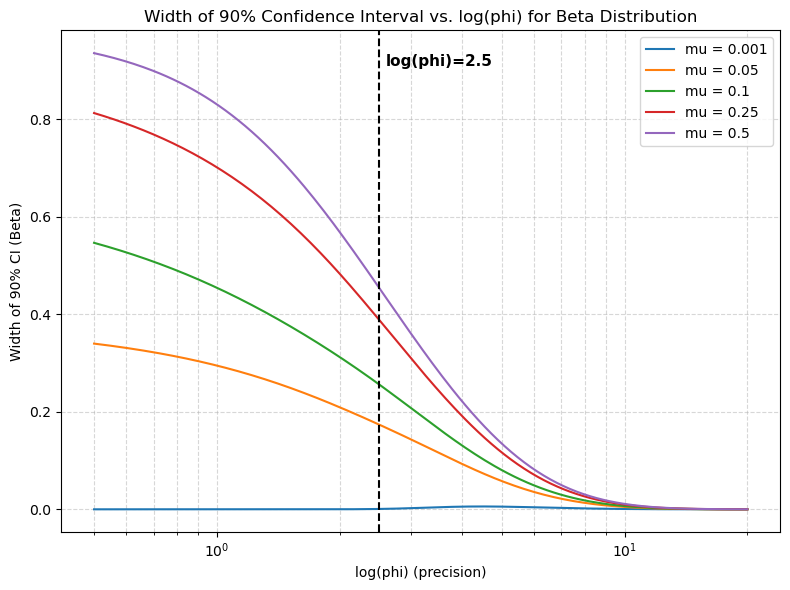

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters
mu_values = [0.001, 0.05, 0.1, 0.25, 0.5]
log_phi_values = np.logspace(np.log10(0.5), np.log10(20), 200)

plt.figure(figsize=(8, 6))
for mu in mu_values:
    phi_values = np.exp(log_phi_values)
    var = mu*(1 - mu)/(1 + phi_values)
    nu = (mu*(1 - mu) / var) - 1
    alpha = mu * nu
    beta_param = (1 - mu) * nu
    # Calculate 5th and 95th percentiles
    ci_5 = beta.ppf(0.05, alpha, beta_param)
    ci_95 = beta.ppf(0.95, alpha, beta_param)
    ci_width = ci_95 - ci_5
    plt.plot(log_phi_values, ci_width, label=f"mu = {mu}")

# Add vertical line at log(phi)=2.5
plt.axvline(2.5, color='black', linestyle='--')
plt.text(2.5+0.1, plt.ylim()[1]*0.95, 'log(phi)=2.5', color='black', ha='left', va='top', rotation=0, fontsize=11, fontweight='bold')

plt.xscale('log')
plt.xlabel('log(phi) (precision)')
plt.ylabel('Width of 90% CI (Beta)')
plt.title('Width of 90% Confidence Interval vs. log(phi) for Beta Distribution')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


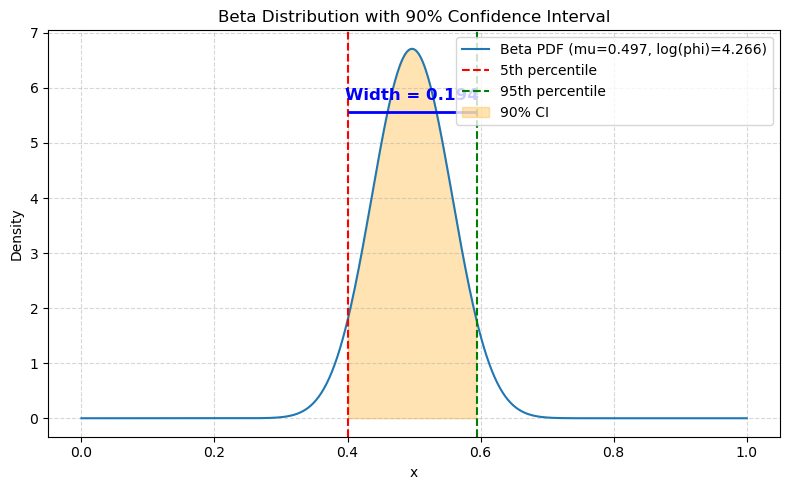

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Set mu and phi for the plot
#mu_plot = 0.05
#log_phi_plot = 3.5
mu_plot = 0.497
log_phi_plot = 4.266
phi_plot = np.exp(log_phi_plot)
var = mu_plot*(1 - mu_plot)/(1 + phi_plot)
nu = (mu_plot*(1 - mu_plot) / var) - 1
alpha_plot = mu_plot * nu
beta_plot = (1 - mu_plot) * nu

x = np.linspace(0, 1, 500)
y = beta.pdf(x, alpha_plot, beta_plot)

# 5th and 95th percentiles
ci5 = beta.ppf(0.05, alpha_plot, beta_plot)
ci95 = beta.ppf(0.95, alpha_plot, beta_plot)
ci_width = ci95 - ci5

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, label=f'Beta PDF (mu={mu_plot}, log(phi)={log_phi_plot})')
ax.axvline(ci5, color='red', linestyle='--', label='5th percentile')
ax.axvline(ci95, color='green', linestyle='--', label='95th percentile')
ax.fill_between(x, y, where=(x >= ci5) & (x <= ci95), color='orange', alpha=0.3, label='90% CI')

# Use axes transform for horizontal line and text at 80% of the y-axis
ax.hlines(0.8, ci5, ci95, color='blue', linestyle='-', linewidth=2, transform=ax.get_xaxis_transform())
ax.text((ci5 + ci95) / 2, 0.82, f'Width = {ci_width:.3f}', color='blue', ha='center', va='bottom', fontsize=12, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Beta Distribution with 90% Confidence Interval')
ax.legend()
ax.grid(True, ls='--', alpha=0.5)
fig.tight_layout()
plt.show()


In [36]:
0.618-0.377

0.241